--- 1. Customer Frequency & Lifetime Value (LTV) Breakdown ---


,Customer_Count,Total_Revenue,Average_Spend_Per_Customer
Customer_Segment,,,
Repeat Buyer (2-3),13661,9.200760e+07,6735.056234
One-Time Buyer,13062,3.801376e+07,2910.255673
Loyal VIP (4+),2198,2.822326e+07,12840.429204



Generating Customer Segment Visual Asset...
  -> Saved Customer Analysis Chart: D:\e-commerce-data-analytics-project\4_images\07_customer_segments_revenue.png


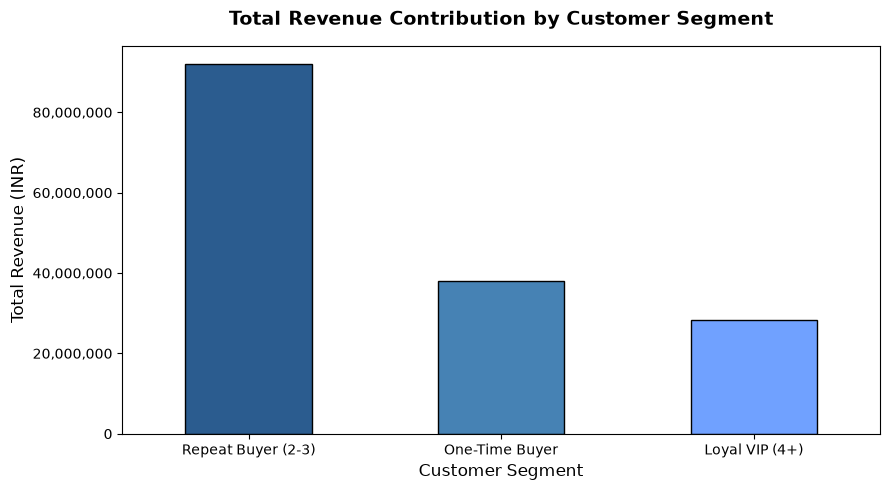

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set paths
PROJECT_DIR = r'D:\e-commerce-data-analytics-project'
VISUALS_DIR = os.path.join(PROJECT_DIR, '4_images')
csv_path = os.path.join(PROJECT_DIR, '1_Data', '2_processed', 'ecommerce_cleaned.csv')

# Load dataset
df = pd.read_csv(csv_path)

print("--- 1. Customer Frequency & Lifetime Value (LTV) Breakdown ---")
# Aggregate metrics per customer (CID)
customer_summary = df.groupby('CID').agg(
    Total_Orders=('TID', 'count'),
    Total_Spend=('Net Amount', 'sum'),
    Avg_Order_Value=('Net Amount', 'mean')
).reset_index()

# Segment customers based on order frequency
def segment_customer(orders):
    if orders == 1:
        return 'One-Time Buyer'
    elif orders <= 3:
        return 'Repeat Buyer (2-3)'
    else:
        return 'Loyal VIP (4+)'

customer_summary['Customer_Segment'] = customer_summary['Total_Orders'].apply(segment_customer)

# Display segment counts and revenue contribution
segment_performance = customer_summary.groupby('Customer_Segment').agg(
    Customer_Count=('CID', 'count'),
    Total_Revenue=('Total_Spend', 'sum'),
    Average_Spend_Per_Customer=('Total_Spend', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

display(segment_performance)

# --- 2. Generate Customer Segmentation Chart ---
print("\nGenerating Customer Segment Visual Asset...")
plt.figure(figsize=(9, 5), dpi=100)
ax = segment_performance['Total_Revenue'].plot(kind='bar', color=['#2b5c8f', '#4682b4', '#70a1ff'], edgecolor='black')
plt.title('Total Revenue Contribution by Customer Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Revenue (INR)', fontsize=12)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.tight_layout()

# Save image into 4_images with professional naming
cust_chart_path = os.path.join(VISUALS_DIR, '07_customer_segments_revenue.png')
plt.savefig(cust_chart_path)
print(f"  -> Saved Customer Analysis Chart: {cust_chart_path}")
plt.show()

Generating Average Spend per Customer Visual Asset...
  -> Saved Customer Analysis Chart: D:\e-commerce-data-analytics-project\4_images\08_customer_avg_spend.png


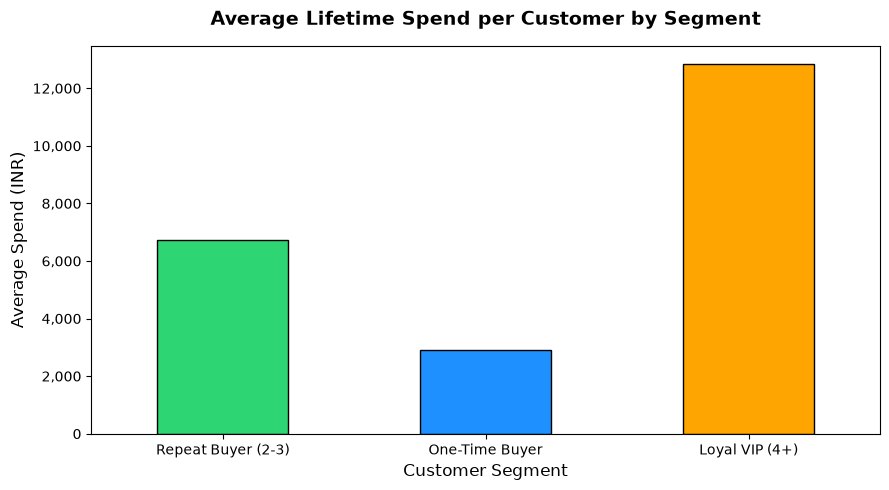


✅ Customer Analysis Phase Complete! All customer charts are safely stored in your '4_images' folder.


In [2]:
# --- 2. Generate Average Spend per Customer Chart ---
print("Generating Average Spend per Customer Visual Asset...")
plt.figure(figsize=(9, 5), dpi=100)

ax = segment_performance['Average_Spend_Per_Customer'].plot(
    kind='bar', color=['#2ed573', '#1e90ff', '#ffa502'], edgecolor='black'
)

plt.title('Average Lifetime Spend per Customer by Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Average Spend (INR)', fontsize=12)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.tight_layout()

# Save image into 4_images with professional naming
avg_spend_path = os.path.join(VISUALS_DIR, '08_customer_avg_spend.png')
plt.savefig(avg_spend_path)
print(f"  -> Saved Customer Analysis Chart: {avg_spend_path}")
plt.show()

print("\n✅ Customer Analysis Phase Complete! All customer charts are safely stored in your '4_images' folder.")

--- Customer Churn & Retention Metrics ---


,Customer_Count,Percentage (%)
Status,,
Retained / Repeat,15859,54.84
One-Time / Churned,13062,45.16



Generating Churn & Retention Visual Asset...
  -> Saved Churn Chart: D:\e-commerce-data-analytics-project\4_images\09_customer_churn_analysis.png


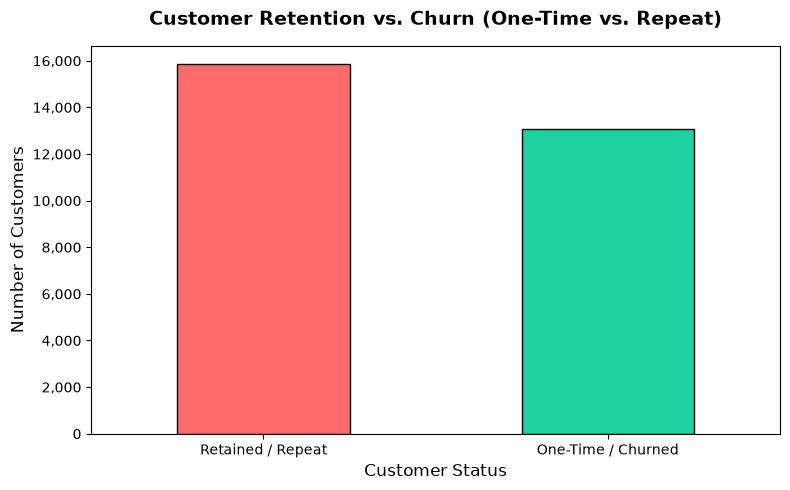


✅ Customer Churn Analytics complete! Asset '09_customer_churn_analysis.png' is saved.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Paths Configuration ---
PROJECT_DIR = r'D:\e-commerce-data-analytics-project'
VISUALS_DIR = os.path.join(PROJECT_DIR, '4_images')
csv_path = os.path.join(PROJECT_DIR, '1_Data', '2_processed', 'ecommerce_cleaned.csv')

# Load dataset
df = pd.read_csv(csv_path)

# --- 1. Churn & Retention Calculation ---
print("--- Customer Churn & Retention Metrics ---")
customer_freq = df.groupby('CID')['TID'].count().reset_index()
customer_freq.rename(columns={'TID': 'Order_Count'}, inplace=True)

# Categorize into Churned (1 order) vs Retained (2+ orders)
customer_freq['Status'] = customer_freq['Order_Count'].apply(lambda x: 'One-Time / Churned' if x == 1 else 'Retained / Repeat')

churn_counts = customer_freq['Status'].value_counts()
churn_percentage = customer_freq['Status'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Customer_Count': churn_counts,
    'Percentage (%)': churn_percentage.round(2)
})
display(summary_df)

# --- 2. Generate Churn & Retention Chart ---
print("\nGenerating Churn & Retention Visual Asset...")
plt.figure(figsize=(8, 5), dpi=100)

colors = ['#ff6b6b', '#1dd1a1'] # Soft red for churned/one-time, green for retained
ax = churn_counts.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Customer Retention vs. Churn (One-Time vs. Repeat)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.tight_layout()

# Save image into 4_images with sequential naming
churn_path = os.path.join(VISUALS_DIR, '09_customer_churn_analysis.png')
plt.savefig(churn_path)
print(f"  -> Saved Churn Chart: {churn_path}")
plt.show()

print("\n✅ Customer Churn Analytics complete! Asset '09_customer_churn_analysis.png' is saved.")